<a id='table_of_contents'></a>

0. [Import libraries](#imports)
1. [Load data](#load_data)
2. [Process text](#process_text)

# 0. Import libraries <a id='imports'></a>
[Back to top](#table_of_contents)

In [ ]:
%reload_ext autoreload
%autoreload 2

import inspect
import re
from inspect import Parameter
from pathlib import Path
from types import MappingProxyType

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import spacy
import umap.umap_ as umap
from nltk import download as nltk_download
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

from coffee.config import Config

!python -m spacy download en_core_web_sm

# Download necessary NLTK resources
nltk_download("punkt")
nltk_download("stopwords")
nltk_download("wordnet")
nltk_download("averaged_perceptron_tagger")
nltk_download("omw-1.4")

# 1. Load data <a id='load_data'></a>
[Back to top](#table_of_contents)

In [ ]:
# Define project directories
BASE_DIR: Path = Config.PROJECT_ROOT
DATA_DIR: Path = Config.DATA_DIR

# Load data
df: pd.DataFrame = pd.read_csv(
    DATA_DIR / "intermediate" / "25072024_reviews_openrefine.csv"
)

df.head()

# 2. Processing text: comparing spaCy and NLTK <a id='process_text'></a>

Text data must be processed before it can be used in machine learning models. This processing includes tokenization, lemmatization, and removing stopwords and punctuation. Here we will try out two popular libraries for text processing: spaCy and NLTK.


## 2.1. NLTK

NLTK (natural language toolkit) is an extensive library for a wide range of NLP tasks. First released in 2001 it is the older of the two. It contains a lot of functionality, but requires more manual work to get started.


In [17]:
def get_wordnet_tag(treebank_tag: str) -> str:
    """
    Transform treebank parts-of-speech tags to wordnet tags for WordNet lemmatizer.
    """
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        # The default pos in lemmatization is Noun
        return wordnet.NOUN


def process_row(
    text: str, processor: WordNetLemmatizer | PorterStemmer, filter_adv: bool = False
) -> str:
    """Preparing text for TF-IDF vectorization."""

    # Convert to lowercase and remove non-alphabetic characters
    processed_text: str = re.sub(r"[^a-z]", " ", text.lower())

    # Tokenize the text
    tokens: list[str] = word_tokenize(processed_text)

    # POS tagging. NLTK POS tags are based solely on token, without considering context.
    tagged_tokens: list[tuple[str, str]] = pos_tag(tokens)

    if filter_adv:
        tagged_tokens = [
            (token, tag) for token, tag in tagged_tokens if not tag.startswith("R")
        ]

    # Apply the processor (lemmatizer or stemmer)
    if isinstance(processor, WordNetLemmatizer):
        processed_tokens = [
            processor.lemmatize(token, pos=get_wordnet_tag(tag))
            for token, tag in tagged_tokens
        ]
    elif isinstance(processor, PorterStemmer):
        processed_tokens = [processor.stem(token) for token in tokens]
    else:
        raise ValueError(
            "Processor must be an instance of either WordNetLemmatizer or PorterStemmer"
        )
    # Join the processed tokens back into a single string and return
    return " ".join(processed_tokens)


def prepare_text_nltk(text: pd.Series) -> pd.Series:
    """Prepare text for TF-IDF vectorization using NLTK."""
    processor: WordNetLemmatizer = WordNetLemmatizer()
    return text.apply(process_row, processor=processor)

In [18]:
# Apply the text processing function to the "blind_assessment" column
prepared_text: pd.Series = prepare_text_nltk(df["blind_assessment"])

# min_df controls rare words, max_df controls common words
vectorizer: TfidfVectorizer = TfidfVectorizer(stop_words="english")
X_nltk_tfidf: csr_matrix = vectorizer.fit_transform(prepared_text)
feature_names: list[str] = vectorizer.get_feature_names_out().tolist()

print(f"n_samples: {X_nltk_tfidf.shape[0]}, n_features: {X_nltk_tfidf.shape[1]}")
print(f"{X_nltk_tfidf.nnz / np.prod(X_nltk_tfidf.shape) * 100:.3f}% non-zero elements")

n_samples: 7563, n_features: 4103
0.667% non-zero elements


In [19]:
df_nltk_tfidf: pd.DataFrame = pd.DataFrame(
    X_nltk_tfidf.toarray(), columns=feature_names
)

print(X_nltk_tfidf.toarray().shape)

# Check that the number of rows matches
assert df_nltk_tfidf.shape[0] == df.shape[0]

(7563, 4103)


In [ ]:
def plot_wordcloud(
    word_scores: dict[str, float], fout: Path, title: str | None = None, **kwargs
):
    """Plotting a wordcloud from a dictionary of word scores."""

    valid_args: MappingProxyType[str, Parameter] = inspect.signature(
        WordCloud
    ).parameters
    for key in kwargs:
        if key not in valid_args:
            raise ValueError(f"Invalid keyword argument: {key}")

    wordcloud = WordCloud(**kwargs)
    wordcloud.generate_from_frequencies(word_scores)

    plt.figure(figsize=(20, 10), dpi=300)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    if title:
        plt.title(title, fontsize=20)
    plt.savefig(fout, bbox_inches="tight")
    plt.show()


output_path: Path = BASE_DIR / "imgs" / "blind_assessment_tfidf_wordcloud.png"
tfidf_scores: np.ndarray = X_nltk_tfidf.sum(axis=0).A1

word_scores: dict[str, float] = dict(zip(feature_names, tfidf_scores, strict=True))

plot_wordcloud(
    word_scores,
    fout=output_path,
    width=1600,
    height=800,
    background_color="white",
    max_font_size=200,
    max_words=300,
)

## 2.2 spaCy

spaCy is a more modern library, Verision 1.0 was release in 2016. Whereas NLTK is used for research and teaching, spaCy was created to be fast and efficient for use in production. It is easy to use with a lot of built-in functionality.

In [7]:
# Load english pipeline
nlp = spacy.load("en_core_web_sm")


def prepare_text_spacy(text: pd.Series, filter_adv: bool = False) -> pd.Series:
    """Prepare text for TF-IDF vectorization using spaCy."""
    docs = list(nlp.pipe(text.tolist()))
    prepared_text = []
    for doc in docs:
        tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
        if filter_adv:
            tokens = [token for token in tokens if token.pos_ != "ADV"]
        joined_tokens: str = " ".join(tokens)
        prepared_text.append(joined_tokens.lower())
    return pd.Series(prepared_text)

In [8]:
prepared_text_spacy = prepare_text_spacy(df["blind_assessment"])

# Apply TF-IDF vectorization to cleaned_assessment column
vectorizer = TfidfVectorizer(stop_words="english")
X_spacy_tfidf = vectorizer.fit_transform(prepared_text_spacy)  # -> scipy sparse matrix
feature_names = vectorizer.get_feature_names_out()


df_spacy_tfidf = pd.DataFrame(X_spacy_tfidf.toarray(), columns=feature_names)


print(f"n_samples: {X_spacy_tfidf.shape[0]}, n_features: {X_spacy_tfidf.shape[1]}")
print(
    f"{X_spacy_tfidf.nnz / np.prod(X_spacy_tfidf.shape) * 100:.3f}% non-zero elements"
)
# Check that the number of rows match
assert X_spacy_tfidf.shape[0] == df.shape[0]

df_spacy_tfidf.head()

n_samples: 7563, n_features: 3935
0.694% non-zero elements


,abandon,abet,ability,abruptly,absence,absent,absolutely,absorbingly,abstract,abundant,...,young,youth,yummy,yuzu,zatar,zest,zestily,zesty,zimbabwe,zin
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.178925,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [ ]:
output_path = BASE_DIR / "imgs" / "blind_assessment_tfidf_wordcloud_spacy.png"
tfidf_scores = X_spacy_tfidf.mean(axis=0).A1
word_scores: dict[str, float] = dict(zip(feature_names, tfidf_scores, strict=True))

plot_wordcloud(
    word_scores,
    fout=output_path,
    width=1600,
    height=800,
    background_color="white",
    max_font_size=200,
    max_words=300,
)

## 2.3 Comparison of text processing methods

In [20]:
nltk_sum = (
    df_nltk_tfidf.sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "nltk", 0: "nltk_score"})
)

spacy_sum = (
    df_spacy_tfidf.sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "spacy", 0: "spacy_score"})
)


df_means = pd.concat([nltk_sum, spacy_sum], axis=1).assign(
    is_same=lambda x: (x["nltk"] == x["spacy"]).astype(int)
)


df_means.head(20)
print(spacy_sum.shape)
print(nltk_sum.shape)


df_means.head(50)

(3935, 2)
(4103, 2)


,nltk,nltk_score,spacy,spacy_score,is_same
0,chocolate,483.429352,chocolate,484.594917,1
1,sweet,470.299919,sweet,473.425488,1
2,tone,409.886018,tone,398.813919,1
3,cup,387.452707,cup,389.997445,1
4,aroma,366.838633,aroma,369.108682,1
5,finish,366.309863,finish,368.683020,1
6,mouthfeel,361.239033,mouthfeel,363.514125,1
7,acidity,355.339011,acidity,357.407908,1
8,note,319.340054,note,321.046395,1
9,cocoa,299.514076,cocoa,297.176663,1


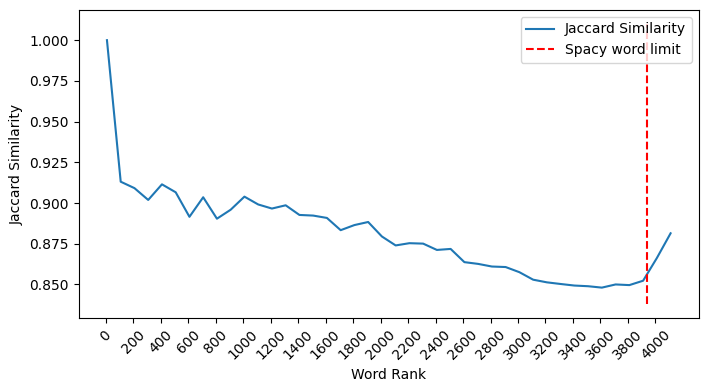

In [28]:
def jaccard_similarity(set1: set, set2: set) -> float:
    """Compute Jaccard similarity between two sets."""
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0


similarity_scores = dict()
for i in range(10, 4200, 100):
    similarity_scores[i] = jaccard_similarity(
        set(df_means["nltk"][:i]), set(df_means["spacy"][:i])
    )


pd.DataFrame(
    similarity_scores.items(), columns=["Top N Words", "Jaccard Similarity"]
).plot(
    x="Top N Words",
    y="Jaccard Similarity",
    kind="line",
    figsize=(8, 4),
    xlabel="Word Rank",
    ylabel="Jaccard Similarity",
)
plt.vlines(
    len(spacy_sum),
    min(similarity_scores.values()) - 0.01,
    max(similarity_scores.values()) + 0.01,
    linestyles="dashed",
    colors="r",
    label="Spacy word limit",
)
# set x-axis ticks
plt.xticks(np.arange(0, 4200, 200), rotation=45)
plt.legend()

<Axes: xlabel='Word Rank', ylabel='Proportion is_same'>

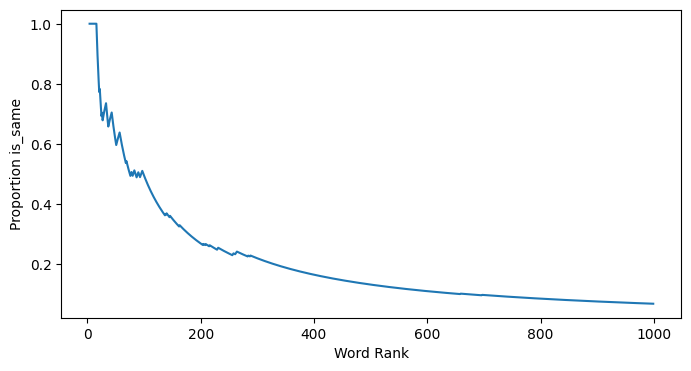

In [29]:
# running average of is_same with window of beginning to current row
# limit to 0 to 1000
df_means[:1000]["is_same"].expanding(5).mean().plot(
    figsize=(8, 4), xlabel="Word Rank", ylabel="Proportion is_same"
)

## Workflow


Consider TruncatedSVD for dimensionality reduction becaue it is sparse data???

https://dev.to/elldora/how-to-plot-feature-importance-using-truncated-svd-166n

data -> pre-process(nltk and spaCy, pick one) -> tf-idf vector

Clustering and visualization:


HDBSCAN -> UMAP for visualization

PCA -> HDBSCAN -> UMAP for visualization

PCA -> UMAP for further dimensionality reduction -> HDBSCAN -> UMAP for visualization


## selection
Kmeans - clusters selected based on silhouette scores
HDBSCAN - ?
PCA - ? 
UMAP - ?

Overall clustering method - ? 


# 3. Dimensionality Reduction <a id='dim_reduction'></a>
[Back to top](#table_of_contents)

### TruncatedSVD (aka LSA)

This transformer performs linear dimensionality reduction by means of truncated singular value decomposition (SVD). Contrary to PCA, this estimator does not center the data before computing the singular value decomposition. This means it can work with *sparse matrices* efficiently. In particular, truncated SVD works on term count/tf-idf matrices as returned by the vectorizers in sklearn.feature_extraction.text. In that context, it is known as *latent semantic analysis* (LSA).


In [30]:
svd = TruncatedSVD(n_components=500)
tfidf_svd = svd.fit_transform(df_spacy_tfidf)
svd.explained_variance_ratio_[:500].sum()

0.8143887033299155

In [31]:
reducer = umap.UMAP(metric="euclidean", n_components=2)
embedding = reducer.fit_transform(tfidf_svd)

In [32]:
px.scatter(
    x=embedding[:, 0],
    y=embedding[:, 1],
    title="UMAP Projection of TF-IDF Vectors",
    labels={"x": "UMAP 1", "y": "UMAP 2"},
    width=800,
    height=600,
)